# 1. Decision Trees and Naive bayes

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler 
from sklearn.datasets import make_moons, make_circles
from sklearn.datasets import load_iris
from sklearn import tree
from sklearn.model_selection import train_test_split 
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.inspection import DecisionBoundaryDisplay  


ImportError: cannot import name 'DecisionBoundaryDisplay' from 'sklearn.inspection' (c:\Users\Ashil_rayan\anaconda3\lib\site-packages\sklearn\inspection\__init__.py)

In [ ]:
datasets = [make_moons(), make_circles()]
names = ['Decision Tree', 'Naive Bayes']
classifiers = [
    tree.DecisionTreeClassifier(),  # Original decision tree
    tree.DecisionTreeClassifier(max_depth = 1),  # Decision tree with max depth of 1
    tree.DecisionTreeClassifier(min_samples_leaf=10),  # Decision tree with minimum samples per leaf set to 10
    GaussianNB()  # Naive Bayes classifier
]


In [ ]:
figure = plt.figure(figsize=(10, 5))

i = 1

# iterate over datasets
for ds_count, ds in enumerate(datasets):
    X, y = ds
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.4, random_state=0
    )
    
    # determining min point and max point and add margin
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    
    # plot dataset
    cm = plt.cm.RdBu
    cm_bright = ListedColormap(['#FF0000', '#0000FF'])
    ax = plt.subplot(len(datasets), len(classifiers) + 1, i)
    
    # plot original
    if ds_count == 0:
        ax.set_title('Input data')
        
    # plot training points
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright, edgecolors='k')
    
    # plot testing points
    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=cm_bright, alpha=0.6, edgecolors="k")
    
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(())
    ax.set_yticks(())
    i += 1
    
    # iterate over classifiers
    for name, clf in zip(names, classifiers):
        ax = plt.subplot(len(datasets), len(classifiers) + 1, i)
        
        # make pipeline to make it easier
        clf = make_pipeline(StandardScaler(), clf)
        clf.fit(X_train, y_train)
        score = clf.score(X_test, y_test)
        DecisionBoundaryDisplay.from_estimator(
            clf, X, cmap=cm, alpha=0.8, ax=ax, eps=0.5
        )
        
        # plot training points
        ax.scatter(
            X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright, edgecolors="k"
        )
        # plot testing points
        ax.scatter(
            X_test[:, 0],
            X_test[:, 1],
            c=y_test,
            cmap=cm_bright,
            edgecolors="k",
            alpha=0.6,
        )
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.set_xticks(())
        ax.set_yticks(())
        
        if ds_count == 0:
            ax.set_title(name)
        ax.text(
            x_max - 0.3,
            y_min + 0.3,
            ("%.2f" % score).lstrip("0"),
            size=15,
            horizontalalignment="right",
        )
        i += 1
        
plt.tight_layout()
plt.show()


<img src="assignment6.jpeg" alt="output of above cell">
'DecisionBoundaryDisplay' did not work with my vs code, so  I ran the code on another pc. this image is the output of the above cell.


Different classifiers make different assumptions about the data. For example, Naive Bayes assumes that the features are conditionally independent given the class label, while decision trees make hierarchical decisions based on feature thresholds. These assumptions can lead to different model behaviors and performance depending on the dataset.

The complexity of the model, controlled by parameters like the maximum depth of a decision tree or the number of neighbors in a k-nearest neighbors classifier, can affect its performance. A more complex model may have higher capacity and can fit the training data more closely, but it may also be prone to overfitting if the dataset is small or noisy.
 
The performance of a classifier can be influenced by the choice of hyperparameters. Hyperparameters control the behavior of the model and are not learned from the data. Grid search or other optimization techniques can be used to find the optimal hyperparameter values, which can significantly impact the model's performance.

# 2. Decision Tree Evaluation

In [3]:
# Load the dataset
data = pd.read_csv('breast-cancer.csv')

data.head() 

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
data.shape 

(569, 32)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [10]:
# Separate features and target variable
X = data.drop(['id', 'diagnosis'], axis=1)
y = data['diagnosis']

# Perform feature scaling using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Check the skewness of the features 
Xscaled = pd.DataFrame(X_scaled)
Xscaled.skew() 

0     0.942380
1     0.650450
2     0.990650
3     1.645732
4     0.456324
5     1.190123
6     1.401180
7     1.171180
8     0.725609
9     1.304489
10    3.088612
11    1.646444
12    3.443615
13    5.447186
14    2.314450
15    1.902221
16    5.110463
17    1.444678
18    2.195133
19    3.923969
20    1.103115
21    0.498321
22    1.128164
23    1.859373
24    0.415426
25    1.473555
26    1.150237
27    0.492616
28    1.433928
29    1.662579
dtype: float64

In [11]:

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Create a decision tree classifier
clf = DecisionTreeClassifier()

# Train the decision tree classifier
clf.fit(X_train, y_train)


DecisionTreeClassifier()

In [12]:
# Predict on the test set
y_pred = clf.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Print accuracy and confusion matrix
print("Accuracy:", accuracy)
print("Confusion Matrix:")
print(cm)

Accuracy: 0.9122807017543859
Confusion Matrix:
[[60  7]
 [ 3 44]]


The model correctly classified 60 samples as negative and 44 samples as positive.
it incorrectly classified 7 samples as positive when they were actually negative and classified 3 samples as negative when they were actually positive.

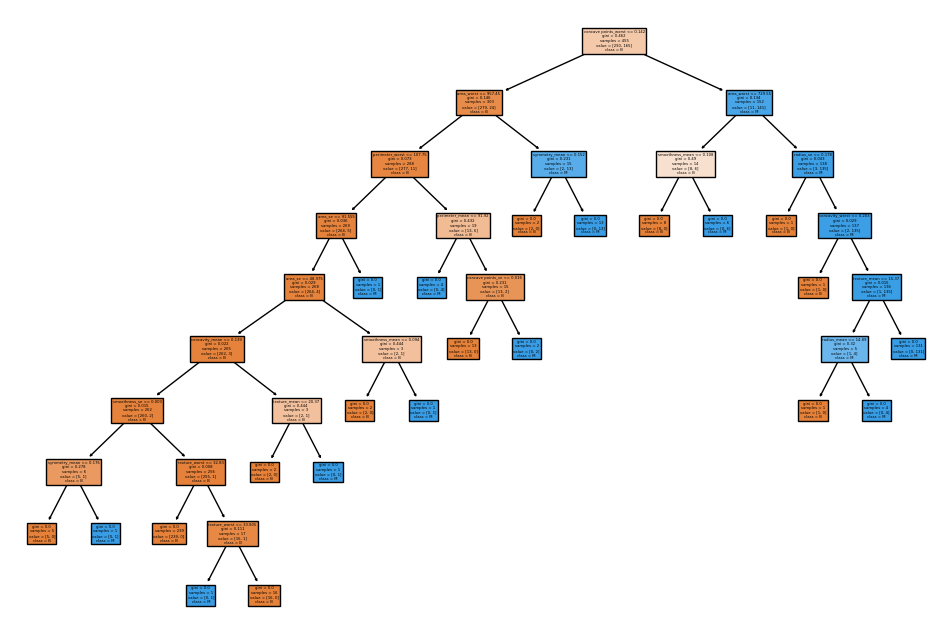

In [14]:
# Visualize the decision tree
plt.figure(figsize=(12, 8))
plot_tree(clf, feature_names=X.columns, class_names=clf.classes_, filled=True)
plt.show()

The decision tree classifier can provide insights into feature importance and how decisions are made. By examining the tree's structure, you can understand which features are considered most important in determining the target class. The decision tree makes decisions based on feature thresholds, where the data is split into different branches based on the feature values. 

By analyzing the decision tree's structure, we can gain insights into the most important features for distinguishing between malignant and benign cases in the breast cancer dataset. These insights can help identify potential biomarkers or factors contributing to cancer diagnoses.

# 3. Naive Bayes

The 'Roommate' column contains unique identifiers for each individual roommate. Each roommate is represented by a different value in this column. Including this column as a feature in a classification procedure would not provide any meaningful information for predicting the test results because the test results are not related to the specific individual roommates but rather to the presence or absence of symptoms. This column does not have any correlation or meaningful relationship with the target variable, which is the test result (Positive or Negative).

In [15]:

# Create a pandas DataFrame with the given data
data = {
    'shivers': ['Y', 'N', 'Y', 'N', 'N', 'Y', 'Y'],
    'running nose': ['N', 'N', 'Y', 'Y', 'N', 'N', 'Y'],
    'headache': ['No', 'Mild', 'No', 'No', 'Heavy', 'No', 'Mild'],
    'test result': ['Negative', 'Negative', 'Positive', 'Negative', 'Positive', 'Negative', 'Positive']
}
df = pd.DataFrame(data)
 
df_encoded = pd.get_dummies(df.drop('test result', axis=1))

# Extract the target variable
y = df['test result']

# Train the Categorical Naive Bayes classifier
clf = CategoricalNB()
clf.fit(df_encoded, y)

CategoricalNB()

In [16]:
# Manually calculate the predicted probabilities for the 5th observation
observation_5 = df_encoded.iloc[4, :]  # Extract the features of the 5th observation

# Predict the probabilities for each class
proba = clf.predict_proba([observation_5])

# Extract the probability for the Negative class (index 0) and Positive class (index 1)
probability_negative = proba[0, 0]
probability_positive = proba[0, 1]

print("Probability of Negative class:", probability_negative)
print("Probability of Positive class:", probability_positive)


Probability of Negative class: 0.5981410732469201
Probability of Positive class: 0.4018589267530796


c:\Users\Ashil_rayan\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but CategoricalNB was fitted with feature names
  warnings.warn(


The assignment has been done by help of Samaneh Shahpouri